SQA 求解器启动: 构建 QUBO (对齐参考建模逻辑)...
Ising 相互作用矩阵 J_isi 检测:
   - 最大值 (Max J): 60.0000
   - 最小值 (Min J): -45.0000

        模拟量子退火 (SQA) 路径规划报告
1. 最终结果能量值 (Ising Energy): -319428623.0273
2. 最终总路径长度: 80.66
3. 求解总耗时: 12.4956 秒

4. 选中的路径边 (Selected Edges):
   [1] S -> W2 (距离: 4.43)
   [2] W1 -> W3 (距离: 14.59)
   [3] W2 -> W9 (距离: 4.23)
   [4] W3 -> W10 (距离: 4.79)
   [5] W4 -> W8 (距离: 3.40)
   [6] W5 -> W11 (距离: 4.96)
   [7] W6 -> W7 (距离: 10.30)
   [8] W7 -> E (距离: 11.76)
   [9] W8 -> W5 (距离: 6.79)
   [10] W9 -> W1 (距离: 5.49)
   [11] W10 -> W4 (距离: 3.13)
   [12] W11 -> W6 (距离: 6.79)



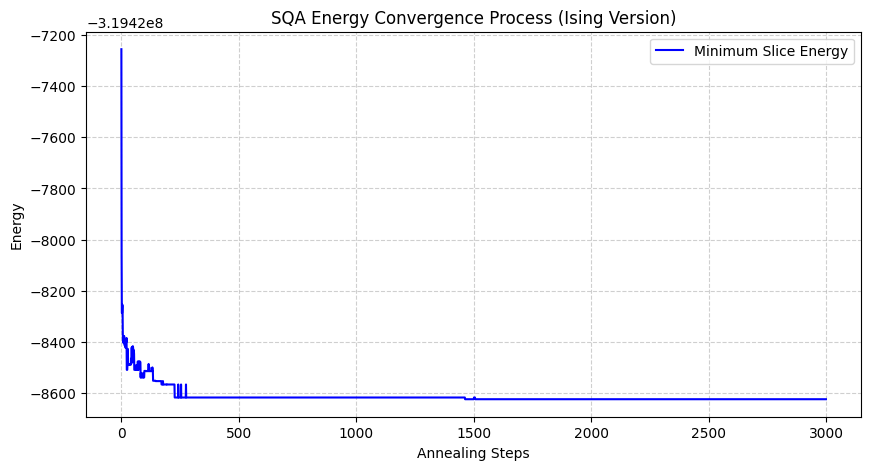

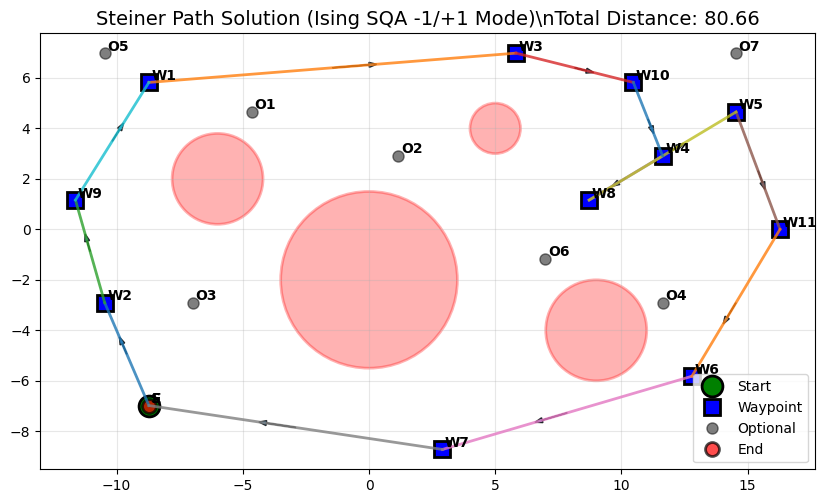

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from math import sqrt, dist
from collections import defaultdict
import numba as nb
import time

# =========================
# 1. 场景构造与几何工具 
# =========================
def create_complex_steiner_scene():
    """
    创建一个更大、更复杂的Steiner TSP场景
    地图范围: ~20x20
    特点: 起终点重合(S/E), 包含必须经由的点(Waypoints)与可选经过的点(Steiner Points)
    修正: 调整障碍物位置，确保不覆盖任何节点
    """
    # start_end_coord = (2.0, 2.0)

    # waypoints = [
    #     (5.0, 15.0), (10.0, 18.0), (18.0, 12.0), 
    #     (15.0, 5.0), (8.0, 2.0)
    # ]

    # optional_points = [
    #     (4.0, 7.0), (7.0, 10.0), (12.0, 8.0),
    #     (14.0, 15.0), (3.0, 12.0), (10.0, 4.0),
    #     (17.0, 18.0), (2.0, 18.0), (18.0, 2.0),
    #     (11.0, 11.0), (6.0, 4.0), (15.0, 9.0)
    # ]

    # obstacles = [
    #     {'center': (8.0, 8.0), 'radius': 1.5},   
    #     {'center': (13.0, 13.0), 'radius': 1.2}, 
    #     {'center': (3.0, 16.0), 'radius': 1.0},  
    #     {'center': (17.0, 6.0), 'radius': 1.5},  
    #     {'center': (9.0, 14.0), 'radius': 1.0}, 
    # ]

    # all_points = [start_end_coord] + waypoints + optional_points + [start_end_coord]
    
    # point_labels = (
    #     ['S'] 
    #     + [f'W{i+1}' for i in range(len(waypoints))] 
    #     + [f'O{i+1}' for i in range(len(optional_points))] 
    #     + ['E']
    # )
    
    # label_to_coord = {label: coord for label, coord in zip(point_labels, all_points)}


    # ========================================
    # 场景1: 仿生微型机器人 - 室内迷宫探测任务
    # ========================================

#     # 坐标单位：分米（dm），适配微尺度环境
#     start_end_coord = (0.0, 0.0)  # 入口Base
    
#     # 所有点位（包括采样点、中继点、充电点）
#     waypoints = [
#         (3, 0),   # 1: 采样点A
#         (6, 0),   # 2: 采样点B
#         (9, 0),   # 3: 采样点C
#         (0, 3),   # 4: 采样点D
#         (6, 3),   # 6: 采样点E
#         (0, 6),   # 8: 采样点F
#         (3, 6),   # 9: 采样点G
#         (9, 6),   # 11: 采样点H
#         (6, 9)    # 13: 采样点I
#     ]

#     optional_points = [
#         (3, 3),   # 5: 中继点R1
#         (9, 3),   # 7: 充电点Chg1
#         (6, 6),   # 10: 中继点R2
#         (3, 9)    # 12: 充电点Chg2
#     ]
#     all_points = [start_end_coord] + waypoints + optional_points + [start_end_coord]
    
#     # 定义可通行边及其代价
#     edge_costs = {
#         (0, 1): 3.2, (1, 2): 3.0, (2, 3): 3.5,
#         (0, 4): 3.0, (1, 5): 4.2, (2, 6): 3.0, (3, 7): 4.5,
#         (4, 5): 3.0, (5, 6): 3.2, (6, 7): 3.0,
#         (4, 8): 3.0, (5, 9): 3.5, (6, 10): 3.0, (7, 11): 3.0,
#         (9, 10): 3.8, (10, 11): 3.2,
#         (9, 12): 5.0, (12, 13): 3.5, (10, 13): 3.0,
#     }
    
#     # 障碍物（迷宫墙壁，通过不可通行的区域隐式表示）
#     obstacles = [
#     {'center': (1.5, 1.5), 'radius': 0.8, 'name': 'Wall-SW'},    # 西南墙壁
#     {'center': (7.5, 1.5), 'radius': 0.8, 'name': 'Wall-SE'},    # 东南墙壁
#     {'center': (4.5, 4.5), 'radius': 1.2, 'name': 'Central-Obs'}, # 中央障碍
#     {'center': (1.5, 7.5), 'radius': 0.8, 'name': 'Wall-NW'},    # 西北墙壁
#     {'center': (7.5, 7.5), 'radius': 0.8, 'name': 'Wall-NE'},    # 东北墙壁
# ]

    
#     point_labels = (
#         ['S'] 
#         + [f'W{i+1}' for i in range(len(waypoints))] 
#         + [f'O{i+1}' for i in range(len(optional_points))] 
#         + ['E']
#     )
    
#     label_to_coord = {label: coord for label, coord in zip(point_labels, all_points)}
    '''
    
    # ========================================
    # 场景2: 无人机低空配送 - 园区走廊网络
    # ========================================
    '''
#     # 坐标单位：百米（hm），适配园区尺度
#     start_end_coord = (5.0, 5.0)  # 起降场Depot
    
#     # 必须配送的订单屋顶
#     waypoints = [
#         (8, 2),    # 1: 订单屋顶A
#         (14, 2),   # 2: 订单屋顶B
#         (20, 2),   # 3: 订单屋顶C
#         (8, 10),   # 4: 订单屋顶D
#         (14, 10),  # 5: 订单屋顶E
#         (20, 6),   # 6: 订单屋顶F
#         (0, 10)    # 7: 订单屋顶G
#     ]

#     optional_points = [
#         (4, 5),    # 8: 充电桩C1
#         (7, 6),    # 9: 充电桩C2
#         (18, 6),   # 10: 充电桩C3
#         (6, -4),   # 11: 走廊接入点W1
#         (12, -4)   # 12: 走廊接入点W2
#     ]

#     all_points = [start_end_coord] + waypoints + optional_points + [start_end_coord]
#     # 审批走廊（可飞行边）
#     edge_costs = {
#         (0, 8): 9.0, (8, 1): 6.0, (1, 9): 7.0, (9, 2): 6.0,
#         (2, 10): 7.0, (10, 3): 6.0,
#         (8, 7): 7.0, (7, 4): 7.0, (4, 9): 7.0, (9, 5): 7.0,
#         (5, 10): 7.0, (10, 6): 7.0,
#         (0, 11): 6.5, (11, 12): 6.0, (12, 6): 12.5, (12, 2): 10.0,
#     }
    
#     obstacles = [
#     {'center': (12.5, 6), 'radius': 3.5, 'name': 'Building-Zone'},  # 核心建筑区
#     {'center': (2, 2), 'radius': 1.8, 'name': 'Factory'},           # 工厂禁飞区
#     {'center': (18, 9), 'radius': 2.5, 'name': 'Restricted-Area'},  # 敏感区域
#     {'center': (10, -1), 'radius': 2.0, 'name': 'Ground-Hazard'},   # 地面危险区
# ]

#     point_labels = (
#         ['S'] 
#         + [f'W{i+1}' for i in range(len(waypoints))] 
#         + [f'O{i+1}' for i in range(len(optional_points))] 
#         + ['E']
#     )
    
#     label_to_coord = {label: coord for label, coord in zip(point_labels, all_points)}
    # ========================================
    # 场景3: 全球气候观测站巡检网络 
    # ========================================

    start_end_coord = (-8.72, -6.98)  # 日内瓦总部

    waypoints = [
        (-8.72, 5.82),    # 1: Greenland-Ice
        (-10.47, -2.91),  # 2: Amazon-Forest
        (5.82, 6.98),     # 3: Svalbard-Arctic
        (11.63, 2.91),    # 4: Siberia-Permafrost
        (14.54, 4.65),    # 5: Tibet-Plateau
        (12.79, -5.82),   # 6: Australia-Outback
        (2.91, -8.72),    # 8: Antarctic-Vostok
        (8.72, 1.16),     # 9: Maldives-Sea
        (-11.63, 1.16),   # 10: Galapagos-Ocean
        (10.47, 5.82),    # 11: Himalaya-Glacier
        (16.28, 0)        # 12: Japan-Typhoon
    ]

    optional_points = [
        (-4.65, 4.65),    # 13: Iceland-Volcano
        (1.16, 2.91),     # 14: Alps-Mountain
        (-6.98, -2.91),   # 15: Brazil-Savanna
        (11.63, -2.91),   # 16: Indonesia-Rainforest
        (-10.47, 6.98),   # 17: Canada-Arctic
        (6.98, -1.16),    # 18: Dubai-Desert
        (14.54, 6.98)     # 19: Mongolia-Steppe
    ]
    all_points = [start_end_coord] + waypoints + optional_points + [start_end_coord]
    # 国际航线
    edge_costs = {
        (0, 14): 3.13,
        (14, 13): 6.07,
        (13, 1): 4.23,
        (1, 17): 2.10,
        (17, 3): 16.28,
        (3, 4): 7.10,
        (4, 19): 5.00,
        (19, 5): 2.33,
        (5, 11): 4.23,
        (11, 12): 8.22,
        (12, 16): 5.49,
        (16, 6): 3.13,
        (6, 8): 10.30,
        (8, 7): 11.76,
        (7, 2): 4.43,
        (2, 15): 3.49,
        (15, 10): 6.18,
        (10, 9): 20.35,
        (9, 18): 2.91,
        (18, 0): 7.07,
    }
    obstacles = [
    {'center': (0, -2), 'radius': 3.5, 'name': 'Building-Zone'},  
    {'center': (-6, 2), 'radius': 1.8, 'name': 'Factory'},          
    {'center': (5, 4), 'radius': 1.0, 'name': 'Restricted-Area'},  
    {'center': (9, -4), 'radius': 2.0, 'name': 'Ground-Hazard'},   
]


    point_labels = (
        ['S'] 
        + [f'W{i+1}' for i in range(len(waypoints))] 
        + [f'O{i+1}' for i in range(len(optional_points))] 
        + ['E']
    )
    
    label_to_coord = {label: coord for label, coord in zip(point_labels, all_points)}
    return all_points, point_labels, label_to_coord, waypoints, optional_points, obstacles, edge_costs

def line_circle_intersection(p1, p2, center, radius):
    """检查线段是否与圆相交"""
    x1, y1 = p1
    x2, y2 = p2
    cx, cy = center
    dx = x2 - x1
    dy = y2 - y1
    a = dx * dx + dy * dy
    if a == 0:
        return (x1 - cx) ** 2 + (y1 - cy) ** 2 <= radius ** 2
    fx = x1 - cx
    fy = y1 - cy
    b = 2 * (fx * dx + fy * dy)
    c = (fx * fx + fy * fy) - radius * radius
    discriminant = b * b - 4 * a * c
    if discriminant < 0:
        return False
    discriminant = sqrt(discriminant)
    t1 = (-b - discriminant) / (2 * a)
    t2 = (-b + discriminant) / (2 * a)
    return (0 <= t1 <= 1) or (0 <= t2 <= 1)


def calculate_edge_weight(p1, p2, obstacles, obstacle_penalty=1e6, base_distance_weight=1.0):
    for obstacle in obstacles:
        if line_circle_intersection(p1, p2, obstacle['center'], obstacle['radius']):
            return float(obstacle_penalty)
    return dist(p1, p2) * float(base_distance_weight)

# =========================
# 2. 可视化工具 
# =========================
def visualize_solution(all_points, point_labels, label_to_coord, obstacles, selected_edges, total_distance):
    fig, ax = plt.subplots(figsize=(10, 8))
    for label, coord in label_to_coord.items():
        x, y = coord
        if label == 'S':
            ax.plot(x, y, 'go', markersize=15, label='Start', markeredgecolor='black', markeredgewidth=2)
        elif label == 'E':
            ax.plot(x, y, 'ro', markersize=10, label='End', markeredgecolor='black', markeredgewidth=2, alpha=0.7)
        elif label.startswith('W'):
            ax.plot(x, y, 'bs', markersize=12, label='Waypoint' if label == 'W1' else '',
                    markeredgecolor='black', markeredgewidth=2)
        else:
            ax.plot(x, y, 'ko', markersize=8, alpha=0.5, label='Optional' if label == 'O1' else '')
        ax.text(x + 0.1, y + 0.1, label, fontsize=10, fontweight='bold')

    for obstacle in obstacles:
        circle = patches.Circle(
            obstacle['center'], obstacle['radius'],
            edgecolor='red', facecolor='red', alpha=0.3, linewidth=2
        )
        ax.add_patch(circle)

    for u, v in selected_edges:
        p1 = label_to_coord[u]
        p2 = label_to_coord[v]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], linewidth=2, alpha=0.8)
        mid_x, mid_y = (p1[0] + p2[0]) / 2, (p1[1] + p2[1]) / 2
        dx, dy = p2[0] - p1[0], p2[1] - p1[1]
        ax.arrow(mid_x, mid_y, dx * 0.1, dy * 0.1, head_width=0.2, head_length=0.3, alpha=0.8)

    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', 'box')
    ax.set_title(f'Steiner Path Solution (Ising SQA -1/+1 Mode)\\nTotal Distance: {total_distance:.2f}', fontsize=14)
    ax.legend(loc='best')
    return fig, ax

# =========================
# 3. 核心 SQA 算法 (极限优化版)
# =========================

@nb.njit
def compute_energy_slice(spins, J, h, k):
    """计算单个切片的 Ising 能量 (变量为 -1/+1) - 仅在初始化时使用"""
    # 优化点：调整为 spins[k, :] 获取连续内存的一维数组
    s = spins[k, :]
    energy = 0.0
    for i in range(len(s)):
        energy += h[i] * s[i]
        for j in range(len(s)):
            if i < j:
                energy += J[i, j] * s[i] * s[j]
    return energy

@nb.njit
def sqa_core_numba(J, h, N, P, T, Gamma_0, Gamma_end, tau):
    # 【优化2：内存布局】形状由 (N, P) 改为 (P, N)，内层循环(基于N)将实现内存连续读取
    spins = (np.random.randint(0, 2, (P, N)) * 2 - 1).astype(np.float64)
    energy_history = np.zeros(tau)
    
    # 【优化1：增量计算】预先计算并跟踪每层的能量
    current_energies = np.zeros(P, dtype=np.float64)
    for k in range(P):
        current_energies[k] = compute_energy_slice(spins, J, h, k)
    
    g_step = (Gamma_end / Gamma_0) ** (1.0 / tau)
    gamma = Gamma_0
    
    for t in range(tau):
        tanh_val = np.tanh(gamma / (P * T))
        if tanh_val < 1e-10: tanh_val = 1e-10
        j_perp = -0.5 * T * P * np.log(tanh_val)
        
        for k in range(P):
            for i in range(N):
                current_s = spins[k, i]
                neighbor_sum = 0.0
                for j in range(N):
                    if i != j:
                        neighbor_sum += J[i, j] * spins[k, j]
                
                delta_E_classic = -2.0 * current_s * (h[i] + neighbor_sum)
                
                s_prev = spins[(k - 1) % P, i]
                s_next = spins[(k + 1) % P, i]
                delta_E_quantum = 2.0 * j_perp * current_s * (s_prev + s_next)
                
                total_delta = (delta_E_classic + delta_E_quantum)
                
                # 【优化3：避免极限状态下无用的 exp 计算】
                exponent = total_delta / (P * T)
                if exponent > 20.0:     # 高能量差，翻转概率极小
                    flip_prob = 0.0
                elif exponent < -20.0:  # 能量大幅降低，翻转概率几乎为1
                    flip_prob = 1.0
                else:
                    flip_prob = 1.0 / (1.0 + np.exp(exponent))
                
                if np.random.random() < flip_prob:
                    spins[k, i] = -current_s
                    # 关键操作：能量增量更新，杜绝重算！
                    current_energies[k] += delta_E_classic
        
        # 记录本步最低经典能量（O(P)代价）
        min_step_e = current_energies[0]
        for k_idx in range(1, P):
            if current_energies[k_idx] < min_step_e:
                min_step_e = current_energies[k_idx]
        energy_history[t] = min_step_e
        
        gamma *= g_step
            
    # 找到最终最优切片
    min_e = current_energies[0]
    best_k = 0
    for k in range(1, P):
        if current_energies[k] < min_e:
            min_e = current_energies[k]
            best_k = k
            
    # 返回形状对齐
    return spins[best_k, :], min_e, energy_history

def solve_with_sqa(Q, P=32, T=2, Gamma_0=20.0, Gamma_end=1e-8, tau=2500):
    """将 QUBO 转换为 Ising 变量并调用 SQA"""
    variables = sorted(list(set(k for pair in Q.keys() for k in pair)))
    N = len(variables)
    var_to_idx = {v: i for i, v in enumerate(variables)}
    
    h_isi = np.zeros(N)
    J_isi = np.zeros((N, N))
    
    for (u, v), w in Q.items():
        u_idx, v_idx = var_to_idx[u], var_to_idx[v]
        if u_idx == v_idx:
            h_isi[u_idx] += w / 2.0
        else:
            val = w / 4.0
            J_isi[u_idx, v_idx] += val
            J_isi[v_idx, u_idx] += val
            h_isi[u_idx] += val
            h_isi[v_idx] += val
    
    j_max = np.max(J_isi)
    j_min = np.min(J_isi)
    print(f"Ising 相互作用矩阵 J_isi 检测:")
    print(f"   - 最大值 (Max J): {j_max:.4f}")
    print(f"   - 最小值 (Min J): {j_min:.4f}")
            
    best_config, min_energy, energy_history = sqa_core_numba(J_isi, h_isi, N, P, T, Gamma_0, Gamma_end, tau)
    
    final_sample = {variables[i]: int(best_config[i]) for i in range(N)}
    return final_sample, min_energy, energy_history

# =========================
# 4. 修改后的 QUBO 构建逻辑 
# =========================
def solve_steiner_path_sqa(U, u_star, distances, **kwargs):
    print("SQA 求解器启动: 构建 QUBO (对齐参考建模逻辑)...")
    N = len(U)
    node_to_idx = {node: i for i, node in enumerate(U)}
    idx_to_node = {i: node for i, node in enumerate(U)}
    E_var = lambda u, v: f"e_{u}_{v}"
    X_var = lambda u, v: f"x_{u}_{v}"
    Q = defaultdict(float)

    w_obj = kwargs.get('w_obj', 4.2)
    w_c1 = kwargs.get('w_c1', 120.0)  
    w_c2 = kwargs.get('w_c2', 60.0)  
    w_c3 = kwargs.get('w_c3', 60.0)  
    w_c4 = kwargs.get('w_c4', 100.0)  
    w_bi = kwargs.get('w_bi', 60.0)  

    for u_idx in range(N):
        for v_idx in range(N):
            if u_idx == v_idx: continue
            dist_val = distances.get((idx_to_node[u_idx], idx_to_node[v_idx]), 0.0)
            Q[(E_var(u_idx, v_idx), E_var(u_idx, v_idx))] += w_obj * dist_val

    start_idx = node_to_idx['S']
    end_idx = node_to_idx['E']
    must_nodes = set(u_star) 

    for idx in range(N):
        node = idx_to_node[idx]
        if node not in must_nodes: continue
        
        if node == 'S':
            k_out, k_in = 1, 0
            w = w_c1
        elif node == 'E':
            k_out, k_in = 0, 1
            w = w_c1
        else:
            k_out, k_in = 1, 1
            w = w_c2

        out_vars = [E_var(idx, v) for v in range(N) if idx != v]
        for i, var_i in enumerate(out_vars):
            Q[(var_i, var_i)] += w * (1 - 2 * k_out) 
            for j in range(i + 1, len(out_vars)):
                Q[tuple(sorted((var_i, out_vars[j])))] += 2.0 * w
        
        in_vars = [E_var(u, idx) for u in range(N) if u != idx]
        for i, var_i in enumerate(in_vars):
            Q[(var_i, var_i)] += w * (1 - 2 * k_in)
            for j in range(i + 1, len(in_vars)):
                Q[tuple(sorted((var_i, in_vars[j])))] += 2.0 * w

    for idx in range(N):
        if idx_to_node[idx] in must_nodes: continue
        
        out_vars = [E_var(idx, v) for v in range(N) if idx != v]
        in_vars = [E_var(u, idx) for u in range(N) if u != idx]
        
        for i, vi in enumerate(out_vars):
            Q[(vi, vi)] += w_c3
            for j in range(i + 1, len(out_vars)):
                Q[tuple(sorted((vi, out_vars[j])))] += 2.0 * w_c3
        for i, vi in enumerate(in_vars):
            Q[(vi, vi)] += w_c3
            for j in range(i + 1, len(in_vars)):
                Q[tuple(sorted((vi, in_vars[j])))] += 2.0 * w_c3
        for vo in out_vars:
            for vi in in_vars:
                Q[tuple(sorted((vo, vi)))] -= 2.0 * w_c3

        for i in range(len(out_vars)):
            for j in range(i + 1, len(out_vars)):
                Q[tuple(sorted((out_vars[i], out_vars[j])))] += w_c3
        for i in range(len(in_vars)):
            for j in range(i + 1, len(in_vars)):
                Q[tuple(sorted((in_vars[i], in_vars[j])))] += w_c3

    for u in range(N - 1):
        for v in range(u + 1, N):
            Q[tuple(sorted((E_var(u, v), E_var(v, u))))] += w_bi

    for u in range(N - 2):
        for v in range(u + 1, N - 1):
            for w in range(v + 1, N):
                x_uv, x_uw, x_vw = X_var(u, v), X_var(u, w), X_var(v, w)
                Q[(x_uw, x_uw)] += w_c4
                Q[tuple(sorted((x_uv, x_vw)))] += w_c4
                Q[tuple(sorted((x_uv, x_uw)))] -= w_c4
                Q[tuple(sorted((x_uw, x_vw)))] -= w_c4

    for u in range(N - 1):
        for v in range(u + 1, N):
            x_uv = X_var(u, v)
            e_uv, e_vu = E_var(u, v), E_var(v, u)
            Q[(e_uv, e_uv)] += w_c4
            Q[tuple(sorted((e_uv, x_uv)))] -= w_c4
            Q[tuple(sorted((e_vu, x_uv)))] += w_c4

    sample, energy, history = solve_with_sqa(Q, T=0.5, tau=3000)

    selected_edges, total_distance = [], 0.0
    for u_idx in range(N):
        for v_idx in range(N):
            if u_idx == v_idx: continue
            if sample.get(E_var(u_idx, v_idx), -1) == 1:
                u, v = idx_to_node[u_idx], idx_to_node[v_idx]
                selected_edges.append((u, v))
                total_distance += distances.get((u, v), 0.0)

    return selected_edges, total_distance, energy, history

# =========================
# 5. 主程序
# =========================
def main():
    all_points, point_labels, label_to_coord, waypoints, optional_points, obstacles, edge_costs = create_complex_steiner_scene()
    
    U = point_labels
    u_star = ['S'] + [f'W{i+1}' for i in range(len(waypoints))] + ['E']
    distances = {(u, v): calculate_edge_weight(label_to_coord[u], label_to_coord[v], obstacles) for u in U for v in U if u != v}

    start_time = time.time()
    edges, dist_val, energy, history = solve_steiner_path_sqa(U, u_star, distances)
    end_time = time.time()

    print("\n" + "="*50)
    print("        模拟量子退火 (SQA) 路径规划报告")
    print("="*50)
    print(f"1. 最终结果能量值 (Ising Energy): {energy:.4f}")
    print(f"2. 最终总路径长度: {dist_val:.2f}")
    print(f"3. 求解总耗时: {end_time - start_time:.4f} 秒")
    print("\n4. 选中的路径边 (Selected Edges):")
    if edges:
        for i, (u, v) in enumerate(edges, 1):
            edge_dist = distances.get((u, v), 0.0)
            print(f"   [{i}] {u} -> {v} (距离: {edge_dist:.2f})")
    else:
        print("   (未找到满足约束的路径边)")
    print("="*50 + "\n")

    plt.figure(figsize=(10, 5))
    plt.plot(history, label='Minimum Slice Energy', color='blue', linewidth=1.5)
    plt.title('SQA Energy Convergence Process (Ising Version)')
    plt.xlabel('Annealing Steps')
    plt.ylabel('Energy')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    visualize_solution(all_points, point_labels, label_to_coord, obstacles, edges, dist_val)
    plt.show()

if __name__ == "__main__":
    main()